In [1]:
import pandas as pd
import glob, pickle
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
#from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

# 1. Load and concatenate all batches
files = glob.glob("data_batches/merged_*.pkl")
frames = []
for fp in files:
    with open(fp, "rb") as f:
        batch = pickle.load(f)

        for sample in batch:
            # assume sample = {"params": array([...]), "results": {"positivity_ok": [...], ...}}
            df_params = pd.DataFrame(sample["params"],                              
                                     columns=["m_phi","m_A","sin_ba","tan_beta","lambda6","lambda7","m12_2"])
            df_labels = pd.DataFrame(sample["results"])
            frames.append(pd.concat([df_params, df_labels], axis=1))
df = pd.concat(frames, ignore_index=True)




In [5]:
df

,m_phi,m_A,sin_ba,tan_beta,lambda6,lambda7,m12_2,positivity_ok,unitarity_ok,perturbativity_ok,...,w_total_h2,w_total_top,branching_ratio_h2_gaga,lambda1,lambda2,lambda3,lambda4,lambda5,lambda6,lambda7
0,125.0,300.005318,1.0,10000.0,0.1,0.0,1.215724,1,0,0,...,1.023374e-03,1.338069,0.912715,5.718565e+06,0.257734,2.768660,-1.284071,-1.284071,0.1,0.0
1,125.0,299.995468,1.0,10000.0,0.1,0.0,1.211370,1,0,0,...,1.049373e-03,1.338069,0.912715,5.790373e+06,0.257734,2.769184,-1.284692,-1.284692,0.1,0.0
2,125.0,299.995358,1.0,10000.0,0.1,0.0,1.204504,1,0,0,...,1.090822e-03,1.338069,0.912715,5.903637e+06,0.257734,2.770314,-1.285823,-1.285823,0.1,0.0
3,125.0,299.999140,1.0,10000.0,0.1,0.0,1.211021,1,0,0,...,1.051409e-03,1.338069,0.912715,5.796134e+06,0.257734,2.769314,-1.284786,-1.284786,0.1,0.0
4,125.0,299.994424,1.0,10000.0,0.1,0.0,1.216403,1,0,0,...,1.019520e-03,1.338069,0.912715,5.707359e+06,0.257734,2.768333,-1.283851,-1.283851,0.1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323995,130.0,299.995524,1.0,10000.0,0.1,0.0,1.684027,1,0,0,...,3.477295e-07,1.338069,0.890961,9.701695e+04,0.257734,2.670189,-1.206728,-1.206728,0.1,0.0
323996,130.0,300.003180,1.0,10000.0,0.1,0.0,1.687134,1,0,0,...,7.920151e-08,1.338069,0.890961,4.578118e+04,0.257734,2.669828,-1.206291,-1.206291,0.1,0.0
323997,130.0,300.009341,1.0,10000.0,0.1,0.0,1.680556,1,0,0,...,8.725314e-07,1.338069,0.890961,1.542786e+05,0.257734,2.671035,-1.207437,-1.207437,0.1,0.0
323998,130.0,300.001457,1.0,10000.0,0.1,0.0,1.685229,1,0,0,...,2.212828e-07,1.338069,0.890961,7.719379e+04,0.257734,2.670108,-1.206588,-1.206588,0.1,0.0


In [7]:
cols = [f"lambda{i}" for i in range(1,8)]
print(cols)

sum_lambdas = df[cols].pow(2).sum(axis=1)

['lambda1', 'lambda2', 'lambda3', 'lambda4', 'lambda5', 'lambda6', 'lambda7']


In [11]:
df["m12_2"]

0         1.215724
1         1.211370
2         1.204504
3         1.211021
4         1.216403
            ...   
323995    1.684027
323996    1.687134
323997    1.680556
323998    1.685229
323999    1.683911
Name: m12_2, Length: 324000, dtype: float64

[]

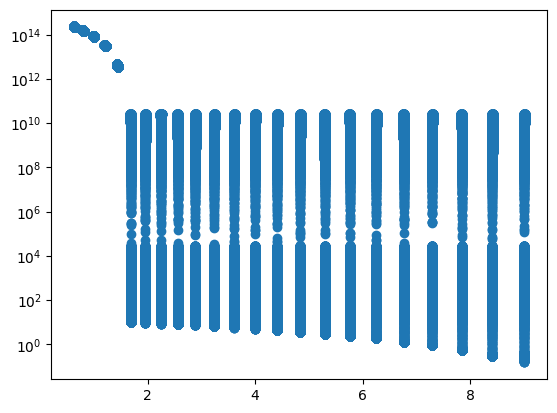

In [17]:
import matplotlib.pyplot as plt


plt.scatter(df["m12_2"],sum_lambdas)
plt.yscale('log')
plt.plot()



## Constrains con $\lambda_j$

En caso de resolver el potencial completo en su forma generica, es posible obtener rapidamente constrains, reglas que deben cumplirse para evitar perder positividad, unitariedad y perturbatividad.

### Positividad:
$$
\lambda_1 > 0
$$

$$
\lambda_2 > 0
$$

$$
\lambda_3 > - \sqrt{\lambda_1 \lambda_2}
$$

$$
\lambda_3 + \lambda_4 - \lambda_5 > - \sqrt{\lambda_1 \lambda_2}
$$

In [4]:
print("## Missing values per column:")
print(df.isnull().sum(), "\n")

## Missing values per column:
m_phi                          0
m_A                            0
sin_ba                         0
tan_beta                       0
lambda6                        0
lambda7                        0
m12_2                          0
positivity_ok              14981
unitarity_ok               14981
perturbativity_ok          14981
w_h2_bb                    14981
w_h2_tautau                14981
w_h2_uu                    14981
w_h2_du                    14981
w_h2_ln                    14981
w_h2_vv                        0
w_h2_gaga                  14981
w_h2_Zga                   14981
w_h2_gg                    14981
w_h2_hh                    14981
w_total_h2                 14981
w_total_top                14981
branching_ratio_h2_gaga    14981
lambda1                    14981
lambda2                    14981
lambda3                    14981
lambda4                    14981
lambda5                    14981
lambda6                    14981
lambda7      

In [ ]:
df.dropna(axis=0, inplace=True)


In [4]:
# 2. Exploratory Data Analysis

print("## Label distribution:")
print(df[["positivity_ok","perturbativity_ok","unitarity_ok"]].mean(), "\n")

print(df[["positivity_ok","perturbativity_ok","unitarity_ok"]].sum(), "\n")

## Label distribution:
positivity_ok        0.735194
perturbativity_ok    0.450102
unitarity_ok         0.466960
dtype: float64 

positivity_ok        238203
perturbativity_ok    145833
unitarity_ok         151295
dtype: int64 



In [ ]:

print("## Basic stats for features:")
print(df[["m_phi","m_A","sin_ba","tan_beta","lambda6","lambda7","m12_2"]].describe(), "\n")


## Basic stats for features:
               m_phi            m_A         sin_ba       tan_beta  \
count  117396.000000  117396.000000  117396.000000  117396.000000   
mean      314.334745     314.985586       0.974996    5006.537637   
std       107.893349     106.790616       0.014434    2883.911465   
min       130.001736     130.004881       0.950000      10.071779   
25%       220.490361     222.514189       0.962500    2510.780852   
50%       310.994780     314.939108       0.974992    5007.539184   
75%       409.513357     407.471695       0.987494    7504.167481   
max       499.999412     499.999452       0.999999    9999.875040   

             lambda6        lambda6        lambda7        lambda7  \
count  117396.000000  117396.000000  117396.000000  117396.000000   
mean        0.000008       0.000008       0.000022       0.000022   
std         0.057732       0.057732       0.057723       0.057723   
min        -0.099999      -0.099999      -0.099999      -0.099999   
25% 

In [31]:

# 3. Train / test split
X = df[["m_phi","m_A","sin_ba","tan_beta","lambda6","lambda7","m12_2"]]
y = df[["positivity_ok","perturbativity_ok","unitarity_ok"]]
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42,
                                                    stratify=y)

# 4. Define and train three multi-output classifiers
models = {
    "Random Forest": MultiOutputClassifier(
        RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    ),
    "XGBoost": MultiOutputClassifier(
        XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
    ),
    "MLP": MultiOutputClassifier(
        MLPClassifier(hidden_layer_sizes=(64,64), max_iter=200, random_state=42)
    )
}

for name, clf in models.items():
    print(f"### Training {name}")
    clf.fit(X_train, y_train)
    print(f"### Evaluating {name}")
    y_pred = clf.predict(X_test)
    print(classification_report(y_test, y_pred, zero_division=0), "\n")


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.